Files already downloaded and verified


C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
训练使用设备: cuda:0
🔥 ResNet50 + RTX 4060 训练开始！冲 90% 准确率！

Epoch 1
Loss: 1.875 | Val Acc: 0.525 | Test Acc: 0.553

Epoch 2
Loss: 1.275 | Val Acc: 0.607 | Test Acc: 0.643

Epoch 3
Loss: 1.075 | Val Acc: 0.651 | Test Acc: 0.673

Epoch 4
Loss: 0.972 | Val Acc: 0.676 | Test Acc: 0.699

Epoch 5
Loss: 0.908 | Val Acc: 0.698 | Test Acc: 0.712

Epoch 6
Loss: 0.851 | Val Acc: 0.710 | Test Acc: 0.723

Epoch 7
Loss: 0.806 | Val Acc: 0.704 | Test Acc: 0.734

Epoch 8
Loss: 0.764 | Val Acc: 0.721 | Test Acc: 0.742

Epoch 9
Loss: 0.740 | Val Acc: 0.722 | Test Acc: 0.746

Epoch 10
Loss: 0.707 | Val Acc: 0.733 | Test Acc: 0.751

Epoch 11
Loss: 0.679 | Val Acc: 0.740 | Test Acc: 0.754

Epoch 12
Loss: 0.658 | Val Acc: 0.738 | Test Acc: 0.756

Epoch 13
Loss: 0.642 | Val Acc: 0.745 | Test Acc: 0.764

Epoch 14
Loss: 0.624 | Val Acc: 0.743 | Test Acc: 0.766

Epoch 15
Loss: 0.597 | Val Acc: 0.739 | Test Acc: 0.768

Epoch 16
Loss: 0.583 | Val Acc: 0.751 | Test Acc: 0.770

Epoch

C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311

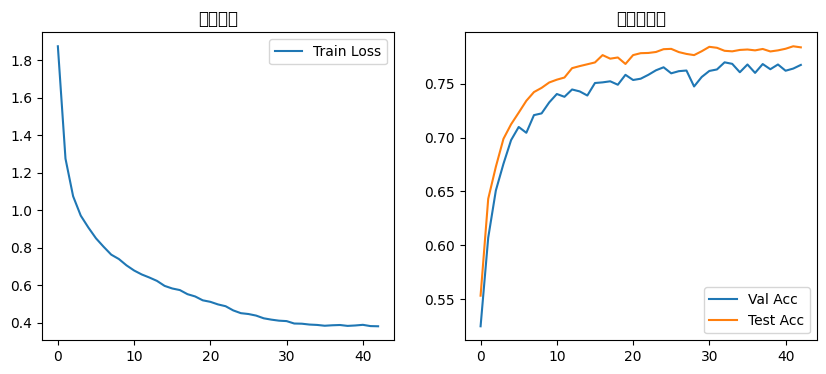

In [1]:
import torch
import os
import matplotlib.pyplot as plt
from torch import nn, optim
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

os.makedirs('./saved_model', exist_ok=True)

# 数据增强
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载 CIFAR10
train_dataset = datasets.CIFAR10(
    root='./dataset/CIFAR10', train=True, transform=train_transform, download=True)
test_dataset = datasets.CIFAR10(
    root='./dataset/CIFAR10', train=False, transform=test_transform, download=True)

batch_size = 128
val_ratio = 0.1
val_size = int(len(train_dataset) * val_ratio)
train_size = len(train_dataset) - val_size
train_subset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# ==================== 🔥 强制使用 RTX 4060 ====================
device = torch.device("cuda:0")
print(f"训练使用设备: {device}")

# ==================== ✅ 换成 ResNet50 (更强!) ====================
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2).to(device)

# 解冻最后两段 + 全连接层，专门为了冲 90% 准确率
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 10).to(device)

# 优化器
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.5)

# 记录
train_loss_list = []
val_acc_list = []
test_acc_list = []
best_acc = 0
best_model = None
patience = 10
counter = 0

# 训练函数
def train():
    model.train()
    loss_sum = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    train_loss_list.append(loss_sum / len(train_loader))

def val():
    global best_acc, best_model, counter
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
    acc = correct / len(val_dataset)
    val_acc_list.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_model = model.state_dict()
        counter = 0
    else:
        counter += 1
    return acc

def test():
    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(1) == y).sum().item()
    acc = correct / len(test_dataset)
    test_acc_list.append(acc)
    return acc

# ==================== 🎯 训练开始：到90%自动停 ====================
print("🔥 ResNet50 + RTX 4060 训练开始！冲 90% 准确率！")
for epoch in range(100):
    print(f"\nEpoch {epoch+1}")
    train()
    v = val()
    t = test()
    scheduler.step(v)
    
    print(f"Loss: {train_loss_list[-1]:.3f} | Val Acc: {v:.3f} | Test Acc: {t:.3f}")

    # 达到 90% 自动停止
    if v >= 0.90:
        print("🎉 准确率达到 90%！自动停止训练！")
        break

    if counter >= patience:
        print("✅ 早停触发，训练结束！")
        break

# 保存模型
if best_model:
    torch.save(best_model, "./saved_model/resnet50_gpu_90acc.pth")
    print("\n✅ ResNet50 最佳模型已保存")

# 画图
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.title('训练损失')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_acc_list, label='Val Acc')
plt.plot(test_acc_list, label='Test Acc')
plt.legend()
plt.title('准确率曲线')
plt.show()

✅ 使用设备: cuda


100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data


C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified


C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\叶湘伦/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100.0%



🔥 RTX 4060 终极训练开始！目标：90%+ 准确率

========== Epoch 1 ==========
Loss: 1.171 | Val Acc: 0.068 | Test Acc: 0.666

========== Epoch 2 ==========
Loss: 0.824 | Val Acc: 0.075 | Test Acc: 0.734

========== Epoch 3 ==========
Loss: 0.725 | Val Acc: 0.078 | Test Acc: 0.751

========== Epoch 4 ==========
Loss: 0.663 | Val Acc: 0.079 | Test Acc: 0.772

========== Epoch 5 ==========
Loss: 0.622 | Val Acc: 0.080 | Test Acc: 0.791

========== Epoch 6 ==========
Loss: 0.581 | Val Acc: 0.081 | Test Acc: 0.801

========== Epoch 7 ==========
Loss: 0.555 | Val Acc: 0.081 | Test Acc: 0.804

========== Epoch 8 ==========
Loss: 0.527 | Val Acc: 0.081 | Test Acc: 0.807

========== Epoch 9 ==========
Loss: 0.504 | Val Acc: 0.081 | Test Acc: 0.802

========== Epoch 10 ==========
Loss: 0.486 | Val Acc: 0.082 | Test Acc: 0.813

========== Epoch 11 ==========
Loss: 0.460 | Val Acc: 0.082 | Test Acc: 0.821

========== Epoch 12 ==========
Loss: 0.440 | Val Acc: 0.083 | Test Acc: 0.820

========== Epoch 13 =========

C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\叶湘伦\AppData\Local\Programs\Python\Python311

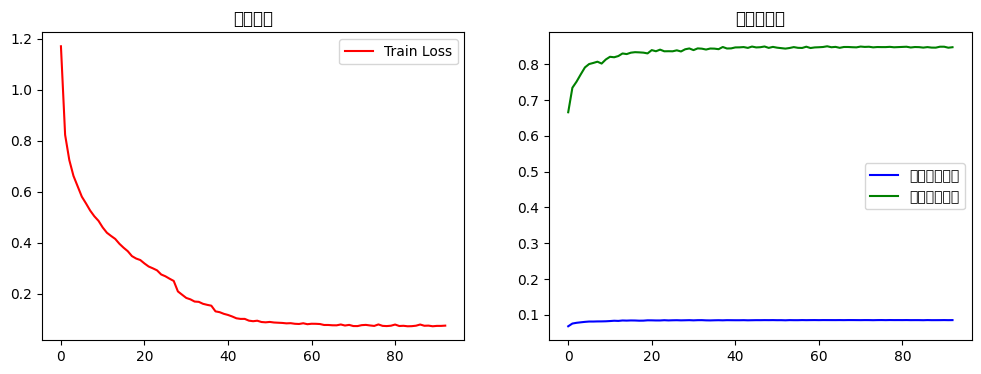

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import os

# ===================== 基础配置 =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("./saved_model", exist_ok=True)
print(f"✅ 使用设备: {device}")

# 超参数
BATCH_SIZE = 128
EPOCHS = 100
LR = 1e-4
patience = 15
counter = 0
best_acc = 0.0

# 记录曲线
train_loss_list = []
val_acc_list = []
test_acc_list = []

# ===================== 数据增强 =====================
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ===================== 加载 CIFAR10 数据集 =====================
train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
val_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=val_test_transform
)
test_dataset = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_test_transform
)

# 训练集/验证集划分
torch.manual_seed(42)
indices = torch.randperm(len(train_dataset)).tolist()
val_split = int(0.1 * len(train_dataset))
val_indices = indices[:val_split]
train_indices = indices[val_split:]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=torch.utils.data.SubsetRandomSampler(train_indices), num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=torch.utils.data.SubsetRandomSampler(val_indices), num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ===================== 模型：ResNet50 预训练 + 解冻关键层 =====================
model = models.resnet50(pretrained=True)
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

# ===================== 优化器 & 损失 & 学习率调度 =====================
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)

# ===================== 训练函数 =====================
def train():
    model.train()
    loss_sum = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        pred = model(x)
        loss = loss_fn(pred, y)
        
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
    
    avg_loss = loss_sum / len(train_loader.dataset)
    train_loss_list.append(avg_loss)

# ===================== 验证函数 =====================
def val():
    global best_acc, counter
    model.eval()
    correct = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            correct += (outputs.argmax(1) == y).sum().item()
    
    acc = correct / len(val_dataset)
    val_acc_list.append(acc)
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "./saved_model/gpu_best_model.pth")
        counter = 0
    else:
        counter += 1
    
    return acc

# ===================== 测试函数 =====================
def test():
    model.eval()
    correct = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            correct += (outputs.argmax(1) == y).sum().item()
    
    acc = correct / len(test_dataset)
    test_acc_list.append(acc)
    return acc

# ===================== 主训练循环 =====================
print("\n🔥 RTX 4060 终极训练开始！目标：90%+ 准确率")
for epoch in range(EPOCHS):
    print(f"\n========== Epoch {epoch+1} ==========")
    train()
    val_acc = val()
    test_acc = test()
    scheduler.step(val_acc)
    
    print(f"Loss: {train_loss_list[-1]:.3f} | Val Acc: {val_acc:.3f} | Test Acc: {test_acc:.3f}")
    
    if val_acc >= 0.90:
        print("\n✅ 验证集准确率达到 90%！自动停止训练")
        break
    
    if counter >= patience:
        print(f"\n✅ 早停触发，共训练 {epoch+1} 轮")
        break

# ===================== 可视化 =====================
print(f"\n🎉 最佳验证准确率: {best_acc:.3f}")
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss', color='r')
plt.title('训练损失')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_acc_list, label='验证集准确率', color='b')
plt.plot(test_acc_list, label='测试集准确率', color='g')
plt.title('准确率曲线')
plt.legend()
plt.show()